In [1]:
import os
import sys
import numpy as np
import datetime
import pandas as pd
from matplotlib import pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
current_path = os.getcwd()
cwd = os.path.dirname(current_path)
sys.path.append(os.path.join(cwd, "utilities"))

# from optimization_dataclasses import Prosumer_Cluster_Data, Market_Data, Bivariate_Pwl_Input, Layer_Data
# from pickle_file_operations import read_pickle, write_pickle
from Energinet_API import energinet_api_wrapper 

In [3]:
market_name = "mFRR_capacity"
price_area = ["DK1"]
start_date = datetime.datetime(2023, 9, 1, 0, 0, 0)

end_date = start_date + datetime.timedelta(days=366) 
timezone = "UTC"
data = energinet_api_wrapper(market_name, price_area, start_date, end_date, timezone)

In [4]:
price_data = pd.DataFrame({"Datetime": pd.to_datetime(data.HourUTC.values), 
                           "mFRR_price": data.mFRR_UpPriceDKK.values})
price_data["month"] = price_data.Datetime.dt.month
price_data["day"] = price_data.Datetime.dt.day

In [5]:
xkcd_palette = ['xkcd:black', 'xkcd:blue', 'xkcd:orange', 'xkcd:green', 'xkcd:red', 'xkcd:purple', 'xkcd:grey']

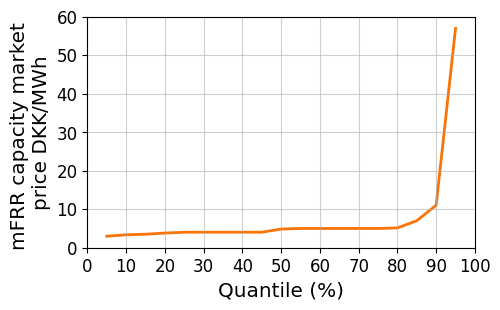

In [6]:
quantiles = price_data.mFRR_price.quantile([0.05 * (i + 1) for i in range(19)])
plt.figure(figsize=(5, 3))
quantiles.plot(linewidth=2, color=xkcd_palette[2], zorder=1)
plt.xlabel("Quantile (%)", fontsize="x-large")
plt.ylabel("mFRR capacity market \nprice DKK/MWh", zorder=0, fontsize="x-large")
plt.xticks(ticks=[0.1 * i for i in range(11)], labels=[f"{100 * 0.1 * (j):.0f}" for j in range(11)], fontsize="large")
plt.yticks([10 * i for i in range(7)], fontsize="large")
plt.grid(zorder=0, alpha=0.6)
plt.savefig(os.path.join(cwd, "images", "quantiles.pdf"), bbox_inches="tight")
plt.show()

In [7]:
def min_max_scale(column):
    return (column - column.min()) / (column.max() - column.min())

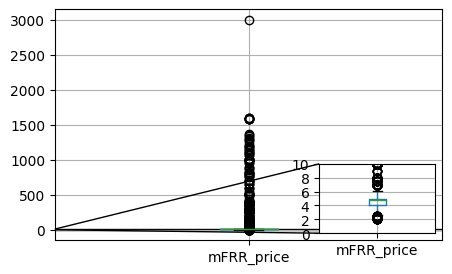

In [35]:
fig, ax = plt.subplots(figsize=(5, 3))
scaled_df = price_data[["mFRR_price"]].apply(min_max_scale)
price_data[["mFRR_price"]].boxplot(ax=ax)
ax_inset = inset_axes(ax, width="30%", height="30%", loc="lower right")
price_data[["mFRR_price"]].boxplot(ax=ax_inset)
ax_inset.set_ylim(1, 10)
ax_inset.set_yticks([2*i for i in range(6)])
mark_inset(ax, ax_inset, loc1=2, loc2=3, fc="none", ec="black")
plt.show()

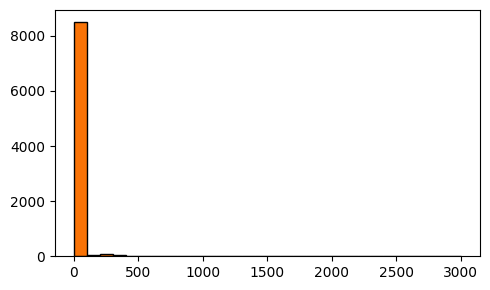

In [11]:
# Plot histograms for each month
fig, axes = plt.subplots(1, 1, figsize=(5, 3))  # 12 months, 3x4 grid

axes.hist(price_data.mFRR_price, bins=30, color='xkcd:orange', edgecolor='black')
# Adjust layout to avoid overlapping
plt.tight_layout()
plt.show()

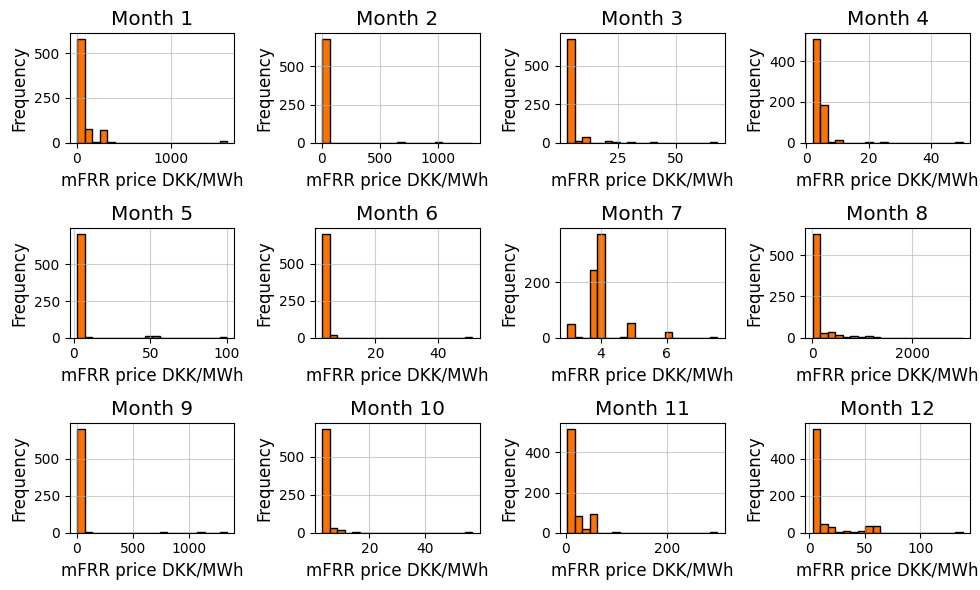

In [13]:
# Plot histograms for each month
fig, axes = plt.subplots(3, 4, figsize=(10, 6))  # 12 months, 3x4 grid
axes = axes.ravel()  # Flattening the axes array for easy indexing

for i in range(1, 13):  # Loop through months 1 to 12
    monthly_data = price_data[price_data.month == i]['mFRR_price']  # Filter data for each month
    # print("Month:", i)
    # print("Minimum and maximum monthly price:", (round(monthly_data.min(), 2), round(monthly_data.max(), 2)))
    axes[i - 1].grid(zorder = 0, alpha = 0.6)
    axes[i - 1].hist(monthly_data, bins=20, color=xkcd_palette[2], edgecolor='black', zorder=1)
    axes[i - 1].set_title(f'Month {i}', fontsize="x-large")
    axes[i - 1].set_xlabel('mFRR price DKK/MWh', fontsize="large")
    axes[i - 1].set_ylabel('Frequency', fontsize="large")


# Adjust layout to avoid overlapping
plt.tight_layout()
plt.savefig(os.path.join(cwd, "images", "price_histograms.pdf"))
plt.show()

In [10]:
month = 1

monthly_data = price_data[price_data.month == month]

for day in monthly_data.day.unique():
    x = monthly_data[monthly_data.day == day].mFRR_price
    print("Day, month:", (day, month))
    print("Min, max, mean:", (round(x.min(), 2), round(x.max(), 2), round(x.mean(), 2)))
    

Day, month: (1, 1)
Min, max, mean: (4.02, 5.14, 4.57)
Day, month: (2, 1)
Min, max, mean: (4.03, 19.98, 8.89)
Day, month: (3, 1)
Min, max, mean: (5.0, 56.01, 28.97)
Day, month: (4, 1)
Min, max, mean: (4.03, 56.02, 19.14)
Day, month: (5, 1)
Min, max, mean: (5.0, 275.14, 130.23)
Day, month: (6, 1)
Min, max, mean: (5.15, 137.98, 21.69)
Day, month: (7, 1)
Min, max, mean: (5.0, 299.98, 192.7)
Day, month: (8, 1)
Min, max, mean: (5.97, 300.1, 178.02)
Day, month: (9, 1)
Min, max, mean: (5.97, 299.95, 103.74)
Day, month: (10, 1)
Min, max, mean: (5.15, 299.97, 146.6)
Day, month: (11, 1)
Min, max, mean: (5.14, 299.84, 138.74)
Day, month: (12, 1)
Min, max, mean: (5.0, 1598.6, 482.88)
Day, month: (13, 1)
Min, max, mean: (4.92, 5.97, 5.19)
Day, month: (14, 1)
Min, max, mean: (5.0, 29.98, 9.07)
Day, month: (15, 1)
Min, max, mean: (5.0, 1578.47, 229.29)
Day, month: (16, 1)
Min, max, mean: (5.0, 249.03, 65.64)
Day, month: (17, 1)
Min, max, mean: (5.0, 283.43, 97.99)
Day, month: (18, 1)
Min, max, mean: (

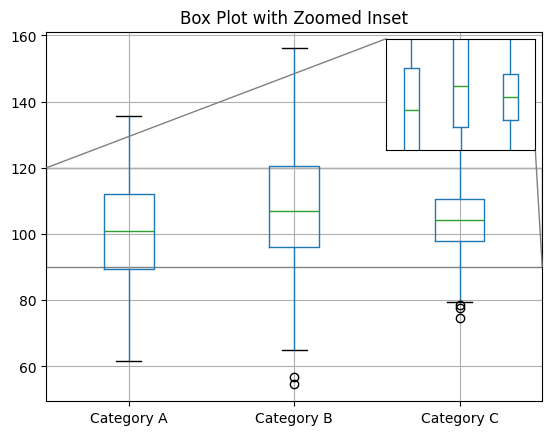

In [33]:
# Sample DataFrame
np.random.seed(0)
data = {
    'Category A': np.random.normal(100, 15, 200),
    'Category B': np.random.normal(110, 20, 200),
    'Category C': np.random.normal(105, 10, 200),
}
df = pd.DataFrame(data)

# Main plot with box plot
fig, ax = plt.subplots()
df.boxplot(ax=ax)
ax.set_title("Box Plot with Zoomed Inset")

# Create an inset axis
ax_inset = inset_axes(ax, width="30%", height="30%", loc="upper right")

# Plot the same box plot on the inset
df.boxplot(ax=ax_inset)

# Define the zoomed-in region
# Here, we are zooming into the area of the y-axis that covers the values around 90 to 120
y1, y2 = 90, 120
ax_inset.set_ylim(y1, y2)

# Optional: Hide x-axis and y-axis labels on the inset
ax_inset.set_xticks([])
ax_inset.set_yticks([])

# Mark the zoomed area on the main plot
mark_inset(ax, ax_inset, loc1=2, loc2=4, fc="none", ec="0.5")

plt.show()